In [1]:
!pip install tqdm scikit-image 
#!pip install monai SimpleITK ipyvolume scikit-image
#set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:true

#cp -r /scratch/$USER/deepPSMAchallenge/deepPSMAchallenge $TMPDIR/dataset/

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/cvmfs/hpc.rug.nl/versions/2023.01/rocky8/x86_64/intel/skylake_avx512/software/Python/3.10.4-GCCcore-11.3.0/bin/python -m pip install --upgrade pip' command.


In [2]:
import os
import glob

import monai
import torch
import torch.serialization
import SimpleITK as sitk
from monai.data.meta_tensor import MetaTensor
from monai.transforms import Transform
from monai.utils.enums import SpaceKeys, TraceKeys
import nibabel
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import ipyvolume as ipv
from PIL import Image

# Define the globals to allow for pickling
safe_globals = [np._core.multiarray._reconstruct, monai.utils.enums.SpaceKeys, monai.data.meta_tensor.MetaTensor, monai.utils.enums.MetaKeys, monai.utils.enums.TraceKeys, np.ndarray, np.dtype, np.dtypes.Float64DType]  # add others as needed

# Add safe globals globally for serialization
torch.serialization.add_safe_globals(safe_globals)


In this notebook we will create two CacheDatasets: one for the PSMA images and one for the FDG images. We do this using the CacheDataset class from Monai

First, we start by building a dictionary that contains the scan and corresponding reference standard

In [3]:
def build_dict_petct(data_path, tracer, mode='train'):
    """
    This function returns a list of dictionaries, each dictionary containing the keys 'img_pet', 'img_ct' and 'mask'
    that returns the path to the corresponding image.

    Args:
        data_path (str): path to the root folder of the data set.
        tracer (str): used tracer. Must correspond to 'PSMA' or 'FDG'.
        mode (str): used subset. Must correspond to 'train', 'val' or 'test'.

    Returns:
        (List[Dict[str, str, str]]) list of the dictionaries containing the paths of PET and CT images and masks
    """
    if mode not in ["train", "val", "test"]:
        raise ValueError(f"Please choose a mode in ['train', 'val', 'test']. Current mode is {mode}.")

    dicts = []

    pt_folders = [f for f in os.listdir(data_path)]
    paths_scan = [os.path.join(data_path, path, tracer) for path in pt_folders]
    for scan_path in paths_scan:
        mask_path = os.path.join(scan_path, "TTB.nii.gz")
        ct_path = os.path.join(scan_path, "CT.nii.gz")
        pet_path = os.path.join(scan_path, "PET.nii.gz")
        totseg_path = os.path.join(scan_path, "totseg_24.nii.gz")
        if os.path.exists(ct_path):
            dicts.append({'pet': pet_path, 'ct':ct_path, 'mask': mask_path, 'totseg': totseg_path})
    return dicts

In [322]:
train_transform = monai.transforms.Compose([
    monai.transforms.LoadImaged(keys=['pet', 'ct', 'totseg', 'mask'], image_only=False),
    monai.transforms.EnsureChannelFirstd(keys=['pet', 'ct', 'totseg', 'mask'], channel_dim="no_channel"),
    monai.transforms.Orientationd(keys=["pet", "ct", 'totseg', "mask"], axcodes='RAS'),
    monai.transforms.Spacingd(keys=['pet', 'ct', 'totseg', 'mask'], pixdim=(2.0, 2.0, 2.0, 2.0), mode=('bilinear', 'bilinear', 'nearest', 'nearest')),
    monai.transforms.ResampleToMatchd(keys=['ct', 'totseg', 'mask'], key_dst='pet', mode=('bilinear', 'nearest', 'nearest'))
])

In [13]:
#data_path = "/scratch/p321870/deepPSMAchallenge/deepPSMAchallenge/"
data_path = "/tmp/dataset/"

# construct list of dictionaries
train_dict_list = build_dict_petct(data_path, "PSMA", mode='train')
#train_dataset = monai.data.PersistentDataset(train_dict_list, transform=train_transform, cache_dir="./cache_dir")

In [324]:
def visualize_full_pet_ct_sample(sample, title=None, slice_idx=70):
    fig, axes = plt.subplots(2, 2, figsize=(30, 10))
    fig.suptitle(title or "PET + CT + Mask + Segmentatie", fontsize=16)
    
    # PET
    axes[0, 0].imshow(np.squeeze(sample['pet'])[:, slice_idx, :], cmap='hot')
    axes[0, 0].set_title('PET')
    axes[0, 0].axis('off')
    
    # CT
    axes[0, 1].imshow(np.squeeze(sample['ct'])[:, slice_idx, :], cmap='gray')
    axes[0, 1].set_title('CT')
    axes[0, 1].axis('off')

    # Mask
    mask = np.squeeze(sample['mask'])[:, slice_idx, :]
    axes[1, 0].imshow(mask, cmap='gray')
    axes[1, 0].set_title('Mask')
    axes[1, 0].axis('off')

    # Segmentatie
    segment = np.squeeze(sample['totseg'])[:, slice_idx, :]
    axes[1, 1].imshow(segment, cmap='gray')
    axes[1, 1].set_title('Segmentatie')
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

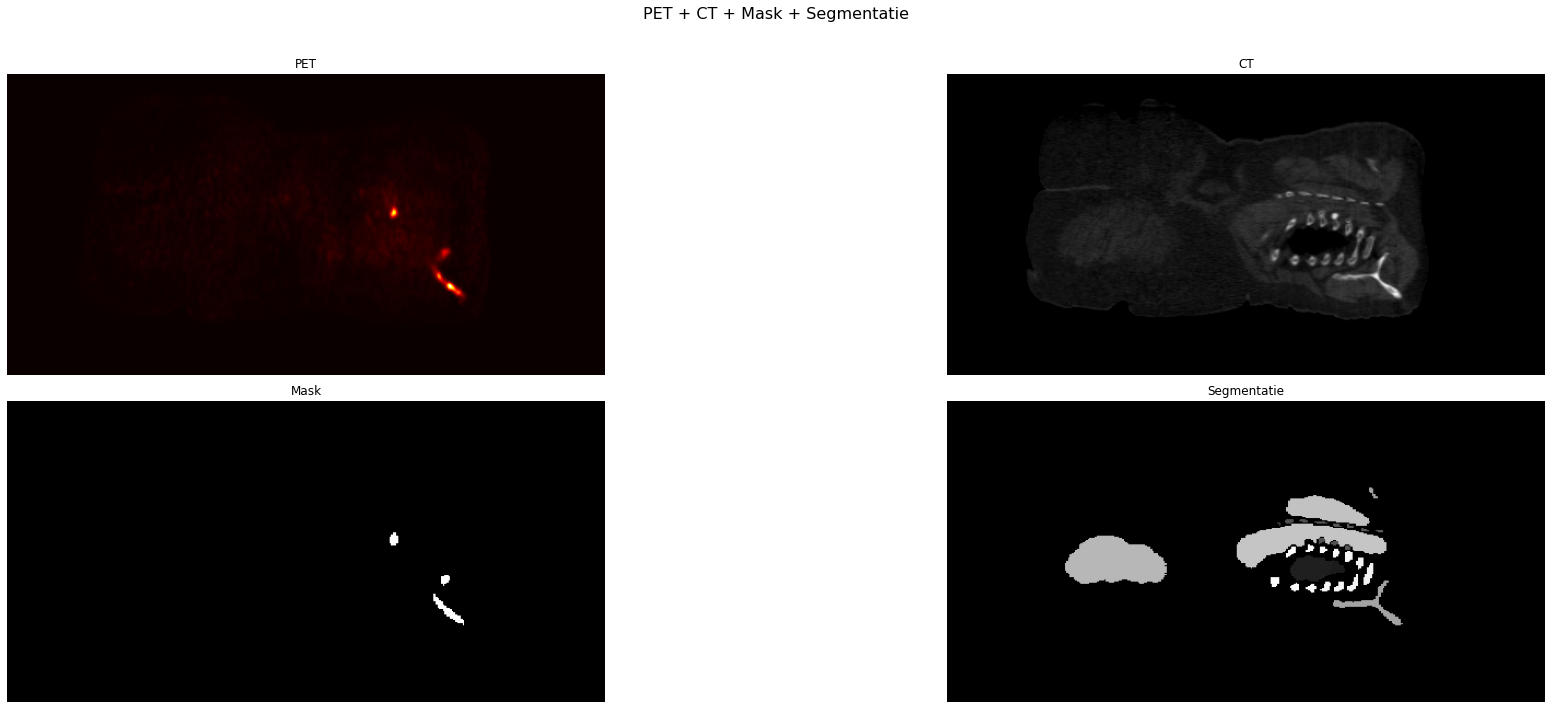

In [325]:
sample = train_dataset[1]
visualize_full_pet_ct_sample(sample)

### Data transforms

First, (1) we add an extra dimension which represents the channel (which is one in our case). Then (2) we make sure that the voxels have the same size and (3) we flip the scans top-bottom. We scale and clip the scans 

In [14]:
train_transform = monai.transforms.Compose([
    
    monai.transforms.LoadImaged(keys=['pet', 'ct', 'totseg', 'mask'], image_only=False),
    monai.transforms.CastToTyped(keys=['pet', 'ct'], dtype=torch.float32),
    monai.transforms.EnsureChannelFirstd(keys=['pet', 'ct', 'totseg', 'mask'], channel_dim="no_channel"),
    monai.transforms.Orientationd(keys=["pet", "ct", 'totseg', "mask"], axcodes='RAS'),
    monai.transforms.Spacingd(keys=['pet', 'ct', 'totseg', 'mask'], pixdim=(2.0, 2.0, 2.0, 2.0), mode=('bilinear', 'bilinear', 'nearest', 'nearest')),
    monai.transforms.ResampleToMatchd(keys=['ct', 'totseg'], key_dst='pet', mode=('bilinear', 'nearest')),
    #monai.transforms.Flipd(keys=["pet", "ct", 'totseg', "mask"], spatial_axis=0),
    monai.transforms.ScaleIntensityRanged(keys=['pet'], a_min=0, a_max=50, b_min=0.0, b_max=1.0, clip=True),
    monai.transforms.ScaleIntensityRanged(keys=['ct'], a_min=-200, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    monai.transforms.RandRotated(keys=['pet', 'ct', 'totseg', 'mask'], range_x=0.34906585, prob=0.2, mode=['bilinear','bilinear', 'nearest', 'nearest']), # 20 degrees
    monai.transforms.SpatialPadd(keys=["pet", "ct", 'totseg', "mask"], spatial_size=(128, 128, 128)),
    monai.transforms.RandSpatialCropd(keys=['pet', 'ct', 'totseg', 'mask'], roi_size=(128, 128, 128), random_center=True, random_size=False),
    monai.transforms.EnsureTyped(keys=['pet', 'ct', 'totseg', 'mask'])
])

train_dataset = monai.data.PersistentDataset(train_dict_list, transform=train_transform, cache_dir="/tmp/cache_dir")
train_loader = monai.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=3)


In [332]:
import monai
from monai.data import MetaTensor
from monai.transforms import SaveImage

sample = train_dataset[1]
saver = SaveImage(output_dir="./tmp", output_postfix="", output_ext=".nii.gz", separate_folder=False)

saver(sample["pet"], meta_data=sample["pet"].meta)
saver(sample["ct"], meta_data=sample["ct"].meta)

2025-06-26 11:49:54,667 INFO image_writer.py:197 - writing: tmp/PET.nii.gz
2025-06-26 11:49:58,504 INFO image_writer.py:197 - writing: tmp/CT.nii.gz


metatensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [12]:
batch = next(iter(train_loader))

def plot_batch_full_sample(batch, axis_mod=0, n_slices=5):
    def _plot(tensor, title, cmap='gray'):
        vol = tensor[0].cpu().numpy()[0]
        spatial_shape = vol.shape
        slice_indices = np.linspace(0, spatial_shape[axis_mod] - 1, n_slices, dtype=int)
        
        fig, axes = plt.subplots(1, n_slices, figsize=(4 * n_slices, 4))

        for i, idx in enumerate(slice_indices):
            if axis_mod == 0:
                img = vol[idx, :, :]
            elif axis_mod == 1:
                img = vol[:, idx, :]
            else:
                img = vol[:, :, idx]
            axes[i].imshow(img, cmap=cmap)
            axes[i].set_title(f"{title} Slice {idx} (axis {axis_mod})")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

    _plot(batch['pet'], "PET", cmap='hot')
    _plot(batch['ct'], "CT")
    _plot(batch['mask'], "Mask", cmap='Greens')
    _plot(batch['totseg'], "Segmentatie", cmap='Reds')

plot_batch_full_sample(batch)

KeyboardInterrupt: 

Now that we have preprocessed our data, lets define the model, loss and optimizer

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=2,       # PET + CT
    out_channels=1,      # background or lesion
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)


In [17]:
from monai.losses import DiceLoss
import torch.optim as optim

loss_function = DiceLoss(to_onehot_y=False, sigmoid=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [18]:
max_epochs = 100

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    for batch in train_loader:

        inputs = torch.cat([batch["pet"], batch["ct"]], dim=1)
        inputs= inputs.to(device)
        labels = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        
    print(f"Epoch {epoch+1}/{max_epochs}, Loss: {epoch_loss/len(train_loader):.4f}")


Epoch 1/100, Loss: 0.9909
Epoch 2/100, Loss: 0.9843
Epoch 3/100, Loss: 0.9860
Epoch 4/100, Loss: 0.9813
Epoch 5/100, Loss: 0.9855
Epoch 6/100, Loss: 0.9873
Epoch 7/100, Loss: 0.9822
Epoch 8/100, Loss: 0.9870
Epoch 9/100, Loss: 0.9828
Epoch 10/100, Loss: 0.9834
Epoch 11/100, Loss: 0.9873
Epoch 12/100, Loss: 0.9864
Epoch 13/100, Loss: 0.9848
Epoch 14/100, Loss: 0.9819
Epoch 15/100, Loss: 0.9849
Epoch 16/100, Loss: 0.9828
Epoch 17/100, Loss: 0.9847
Epoch 18/100, Loss: 0.9866
Epoch 19/100, Loss: 0.9794
Epoch 20/100, Loss: 0.9840
Epoch 21/100, Loss: 0.9767
Epoch 22/100, Loss: 0.9815


KeyboardInterrupt: 